### Project 2 - Classification - Neural network - Naive Bayes - SVM

**In this file:** 
+ Data Preparation + Modeling + Model performance analysis (3 models in the current notebook) + ROI analysis (all 6 models provided for this project)

**On other files:**
+ Business Understanding + Data Undertanding + Evaluation (of analyzed models)
+ *Files Names:* ML_02_Business; ML_02_Model_DecisionTrees; ML_02_Model_NN_NB_SVM; ML_02_Model_KNN; ML_02_Model_LogisticR

#### **Group V**
+ Ana Isabel Moura, 20250168
+ Ayoub Mask, 20250183
+ Beatriz Lobão, 20250566
+ Joao Bernardino, 20250922
+ Lara Pereira, 20250921

## Initializations and data loading

In [1]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce
import collections
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.neural_network import MLPClassifier
from yellowbrick.classifier import ROCAUC
from yellowbrick.classifier import PrecisionRecallCurve


In [2]:
# Loading the dataset and visualizing summary statistics
ds = pd.read_excel('campaign.xlsx', engine='openpyxl')
ds.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2240.0,NaN,NaN,NaN,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,NaN,NaN,NaN,1968.805804,11.984069,1893.0,1959.0,1970.0,1977.0,1996.0
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2216.0,NaN,NaN,NaN,52247.251354,25173.076661,1730.0,35303.0,51381.5,68522.0,666666.0
Kidhome,2240.0,NaN,NaN,NaN,0.444196,0.538398,0.0,0.0,0.0,1.0,2.0
Teenhome,2240.0,NaN,NaN,NaN,0.50625,0.544538,0.0,0.0,0.0,1.0,2.0
Dt_Customer,2240,665,2012-08-31,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,2240.0,NaN,NaN,NaN,49.109375,28.962453,0.0,24.0,49.0,74.0,99.0
MntWines,2237.0,NaN,NaN,NaN,303.838623,336.576209,0.0,24.0,173.0,504.0,1493.0


In [3]:
# Show top rows
ds.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635.0,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11.0,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426.0,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11.0,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173.0,...,5,0,0,0,0,0,0,3,11,0


In [4]:
# 1. Drop the non-informative Z_ columns
ds01 = ds.drop(columns=['Z_CostContact', 'Z_Revenue'])

# 2. Check for exact row duplicates across the entire dataset
duplicate_count = ds01.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")


Number of duplicate rows found: 0


In [5]:
ds01.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2237 non-null   float64
 10  MntFruits            2238 non-null   float64
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2187 non-null   float64
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [6]:
# Calculate the total number of missing values for each column
missing_data = ds01.isnull().sum()

# Filter and display only the columns that have missing data
missing_columns = missing_data[missing_data > 0]
print(missing_columns)

Income          24
MntWines         3
MntFruits        2
MntGoldProds    53
dtype: int64


In [7]:

ds02 = ds01.copy()

# Calculate age based on the current year (2026)
age_values = 2026 - ds02['Year_Birth']

# Find the position of the ID column
id_position = ds02.columns.get_loc('ID')

# Insert the Age column immediately after the ID column
ds02.insert(id_position + 1, 'Age', age_values)

In [8]:
# Drop the Year_Birth column
ds03 = ds02.drop(columns=['Year_Birth'])

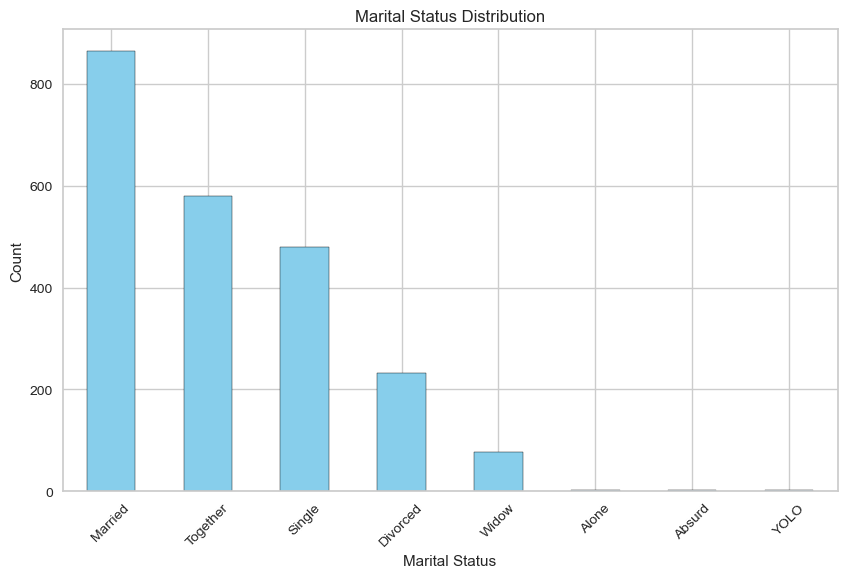

In [9]:
import matplotlib.pyplot as plt

# Count the occurrences of each marital status
marital_counts = ds03['Marital_Status'].value_counts()

# Create the bar chart
marital_counts.plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')

# Add labels and title to the chart
plt.title('Marital Status Distribution')
plt.xlabel('Marital Status')
plt.ylabel('Count')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

In [10]:
# Count the occurrences of each category in the Marital_Status column
marital_status_counts = ds03['Marital_Status'].value_counts()

# Display the counts
print(marital_status_counts)

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [11]:
import pandas as pd

# changing YOLO and Alone to "Single"
ds03['Marital_Status'] = ds03['Marital_Status'].replace(['Alone', 'YOLO'], 'Single')

# Verify the changes
print(ds03['Marital_Status'].value_counts())

Marital_Status
Married     864
Together    580
Single      485
Divorced    232
Widow        77
Absurd        2
Name: count, dtype: int64


In [12]:
# Replace 'Absurd' with 'Married' in the Marital_Status column
ds03['Marital_Status'] = ds03['Marital_Status'].replace('Absurd', 'Married')

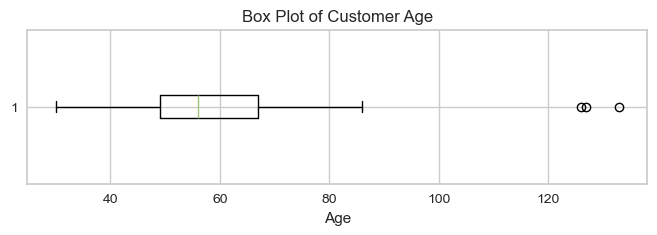

In [13]:
# Create a box plot to identify outliers in the Age column
plt.figure(figsize=(8, 2))
plt.boxplot(ds03['Age'], vert=False)

# Add title and labels
plt.title('Box Plot of Customer Age')
plt.xlabel('Age')

# Display the visualization
plt.show()

In [14]:
# Calculate the first and third quartiles for the Age column
Q1 = ds03['Age'].quantile(0.25)
Q3 = ds03['Age'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataset to isolate the outlier values
age_outliers = ds03[(ds03['Age'] < lower_bound) | (ds03['Age'] > upper_bound)]['Age']

# Display the outlier values
print(age_outliers)

192    126
239    133
339    127
Name: Age, dtype: int64


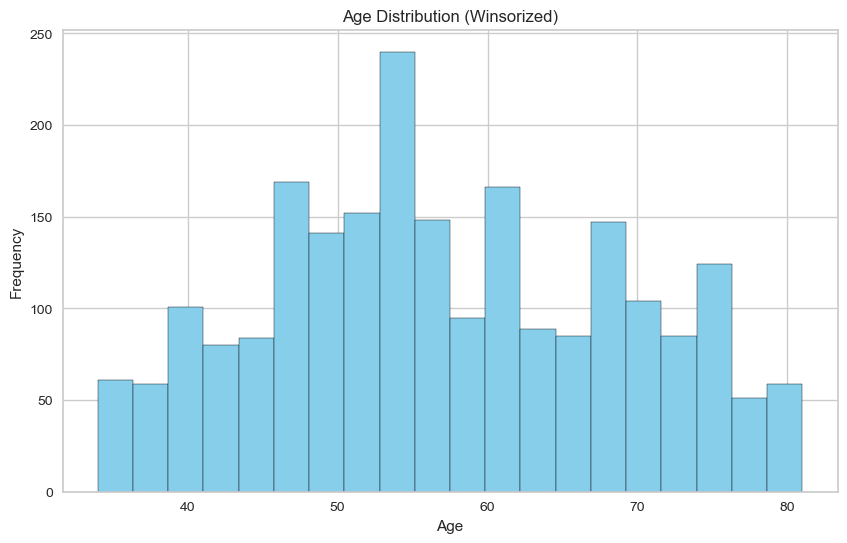

In [15]:
from scipy.stats.mstats import winsorize


ds05 = ds03.copy()

# Apply winsorization to cap the extreme 1% of values on both ends
ds05['Age'] = winsorize(ds05['Age'], limits=[0.01, 0.01])

# Visualize the updated age distribution
plt.figure(figsize=(10, 6))
plt.hist(ds05['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution (Winsorized)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [16]:
# Find the maximum value in the Age column
max_age = ds05['Age'].max()
print(max_age)

81


In [17]:
ds06 = ds05.copy()

# Set negative values in MntFishProducts to 0
ds06.loc[ds06['MntFishProducts'] < 0, 'MntFishProducts'] = 0

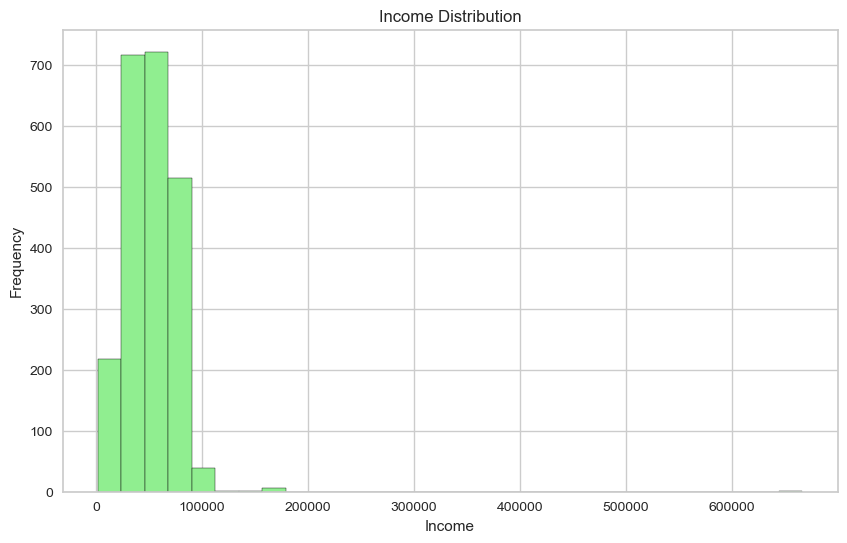

In [18]:
# Visualize the distribution of the Income column, ignoring missing values for the plot
plt.figure(figsize=(10, 6))
plt.hist(ds06['Income'].dropna(), bins=30, color='lightgreen', edgecolor='black')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

In [19]:
ds07 = ds06.copy()

# Calculate the mean of the Income column and round to the nearest integer
mean_income = round(ds07['Income'].mean())

# Fill missing values in the Income column with the calculated mean
ds07['Income'] = ds07['Income'].fillna(mean_income)

# Display the calculated mean and verify missing values are resolved
print(f"Average Income used for filling: {mean_income}")
print(f"Remaining missing values in Income: {ds07['Income'].isnull().sum()}")

Average Income used for filling: 52247
Remaining missing values in Income: 0


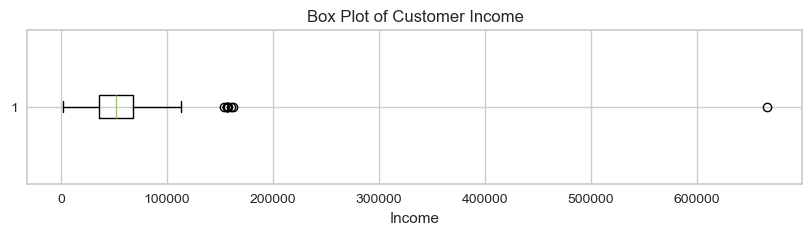

In [20]:
# Create a box plot to identify outliers in the Income column
plt.figure(figsize=(10, 2))
plt.boxplot(ds07['Income'], vert=False)

# Add title and labels
plt.title('Box Plot of Customer Income')
plt.xlabel('Income')

# Display the visualization
plt.show()

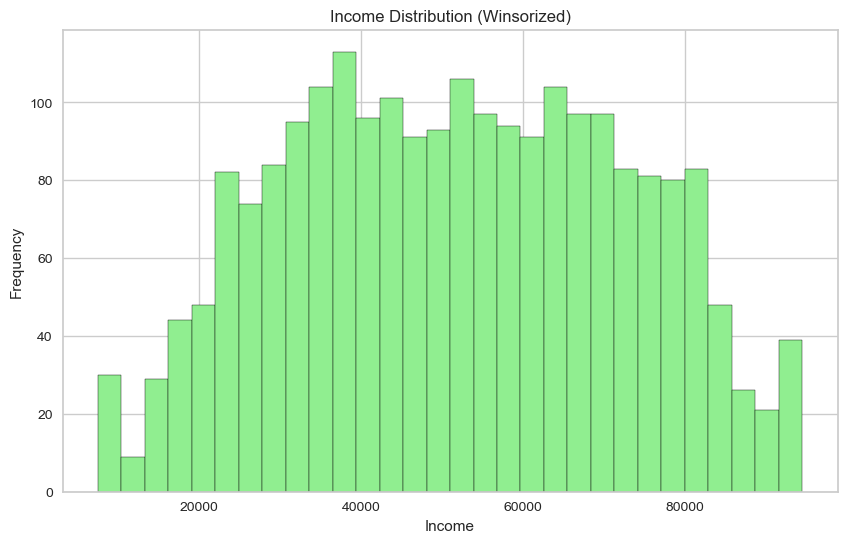

In [21]:

ds08 = ds07.copy()

# Apply winsorization to cap the extreme 1% of values in the Income column
ds08['Income'] = winsorize(ds08['Income'], limits=[0.01, 0.01])

# Visualize the updated Income distribution
plt.figure(figsize=(10, 6))
plt.hist(ds08['Income'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Income Distribution (Winsorized)')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

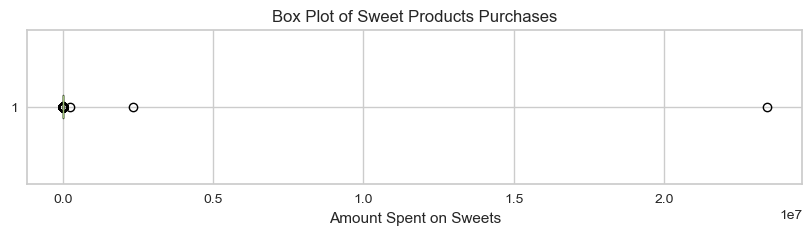

In [22]:
# Create a box plot to identify outliers in the MntSweetProducts column
plt.figure(figsize=(10, 2))
plt.boxplot(ds08['MntSweetProducts'], vert=False)

# Add title and labels
plt.title('Box Plot of Sweet Products Purchases')
plt.xlabel('Amount Spent on Sweets')

# Display the visualization
plt.show()

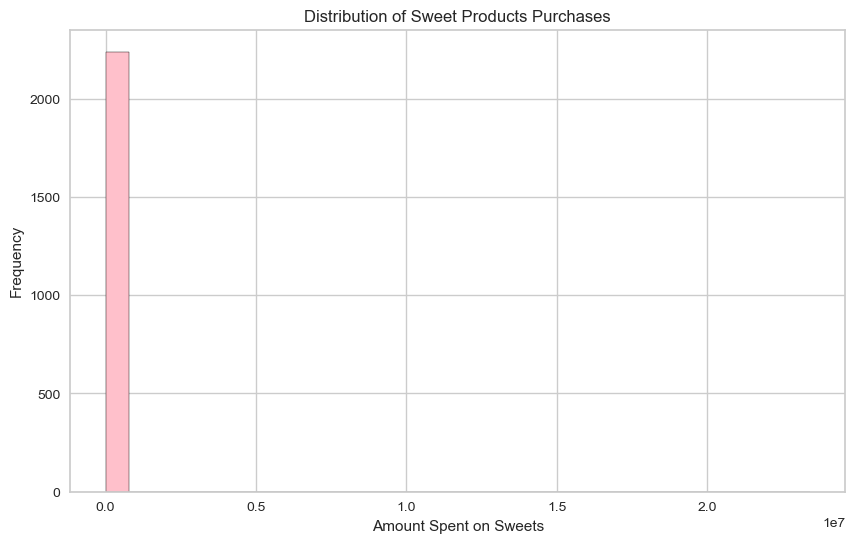

In [23]:
# Visualize the distribution of MntSweetProducts using a histogram
plt.figure(figsize=(10, 6))
plt.hist(ds08['MntSweetProducts'], bins=30, color='pink', edgecolor='black')
plt.title('Distribution of Sweet Products Purchases')
plt.xlabel('Amount Spent on Sweets')
plt.ylabel('Frequency')
plt.show()

c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


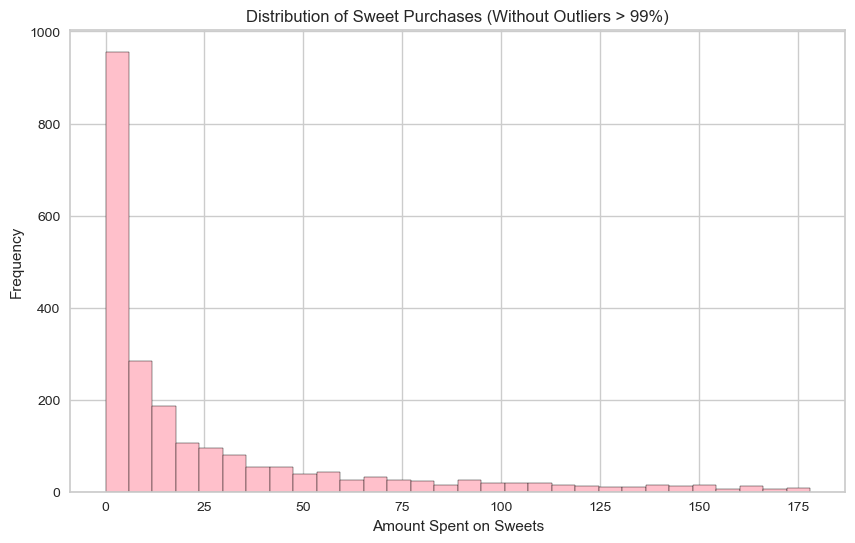

In [24]:
# Calculate the 99th percentile for MntSweetProducts
sweet_99th = ds08['MntSweetProducts'].quantile(0.99)

# Filter the data to exclude values above the 99th percentile
filtered_sweets = ds08[ds08['MntSweetProducts'] <= sweet_99th]['MntSweetProducts']

# Visualize the distribution without the outliers
plt.figure(figsize=(10, 6))
plt.hist(filtered_sweets, bins=30, color='pink', edgecolor='black')
plt.title('Distribution of Sweet Purchases (Without Outliers > 99%)')
plt.xlabel('Amount Spent on Sweets')
plt.ylabel('Frequency')
plt.show()

In [25]:
# Calculate and display the 99th percentile value for MntSweetProducts
sweet_99th_value = ds08['MntSweetProducts'].quantile(0.99)
print(sweet_99th_value)

178.61000000000013


c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [26]:
ds09 = ds08.copy()

ds09.loc[ds09['MntSweetProducts'] > 178, 'MntSweetProducts'] = 178

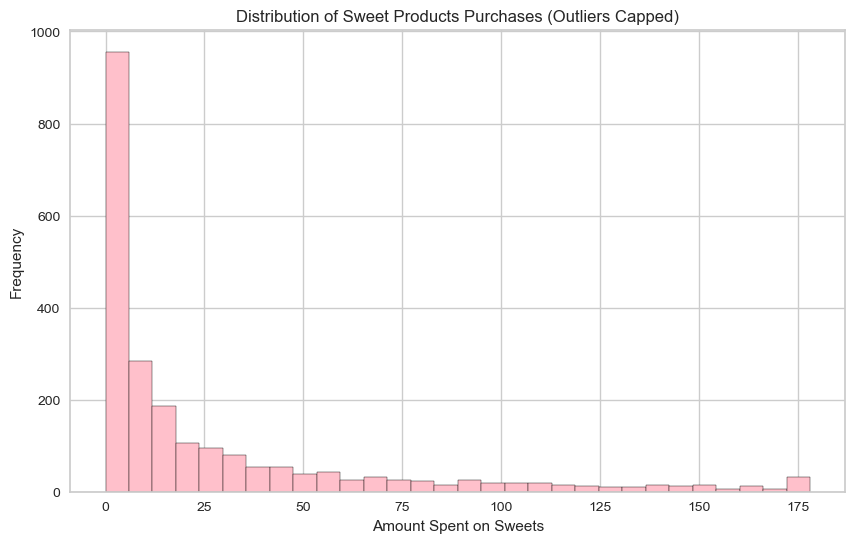

In [27]:
plt.figure(figsize=(10, 6))
plt.hist(ds09['MntSweetProducts'], bins=30, color='pink', edgecolor='black')
plt.title('Distribution of Sweet Products Purchases (Outliers Capped)')
plt.xlabel('Amount Spent on Sweets')
plt.ylabel('Frequency')
plt.show()

In [28]:
ds09.describe(include='all').T

c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2240.0,NaN,NaN,NaN,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Age,2240.0,NaN,NaN,NaN,57.132143,11.666094,34.0,49.0,56.0,67.0,81.0
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,5,Married,866,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2240.0,NaN,NaN,NaN,51774.707143,20619.393904,7500.0,35538.75,51741.5,68289.75,94472.0
Kidhome,2240.0,NaN,NaN,NaN,0.444196,0.538398,0.0,0.0,0.0,1.0,2.0
Teenhome,2240.0,NaN,NaN,NaN,0.50625,0.544538,0.0,0.0,0.0,1.0,2.0
Dt_Customer,2240,665,2012-08-31,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,2240.0,NaN,NaN,NaN,49.109375,28.962453,0.0,24.0,49.0,74.0,99.0
MntWines,2237.0,NaN,NaN,NaN,303.838623,336.576209,0.0,24.0,173.0,504.0,1493.0


In [29]:
ds10 = ds09.copy()

ds10['Dt_Customer'] = pd.to_datetime(ds10['Dt_Customer'])

In [30]:
# Find the earliest (lowest) date
earliest_date = ds10['Dt_Customer'].min()

# Find the most recent (highest) date
most_recent_date = ds10['Dt_Customer'].max()

print(f"Earliest customer enrollment (Lowest): {earliest_date}")
print(f"Most recent customer enrollment (Highest): {most_recent_date}")

Earliest customer enrollment (Lowest): 2012-07-30 00:00:00
Most recent customer enrollment (Highest): 2042-11-09 00:00:00


In [31]:
# the most frequent dates and their exact counts, starting from the highest
ds10['Dt_Customer'].value_counts().head(5)

Dt_Customer
2012-08-31    12
2014-05-12    11
2012-09-12    11
2013-02-14    11
2014-05-22    10
Name: count, dtype: int64

In [32]:
# replacing 2042-11-09 with 2012-11-09
ds10.loc[ds10['Dt_Customer'] == '2042-11-09', 'Dt_Customer'] = pd.to_datetime('2012-11-09')

In [33]:
# replacing 2042-11-09 with 2012-11-09
ds10.loc[ds10['Dt_Customer'] == '2041-02-25', 'Dt_Customer'] = pd.to_datetime('2012-08-12')

reference_date = ds10['Dt_Customer'].max()
ds10['Customer_Tenure_Days'] = (reference_date - ds10['Dt_Customer']).dt.days

In [34]:
# Sort the dates from newest to oldest and display the top 10
top_5_dates = ds10['Dt_Customer'].sort_values(ascending=False).head(5)

print(top_5_dates)

200    2014-06-29
989    2014-06-29
1812   2014-06-28
796    2014-06-28
45     2014-06-28
Name: Dt_Customer, dtype: datetime64[us]


In [35]:
ds10['Enrollment_Year'] = ds10['Dt_Customer'].dt.year
ds10['Enrollment_Month'] = ds10['Dt_Customer'].dt.month

In [36]:
ds11 = ds10.drop(columns=['Dt_Customer'])

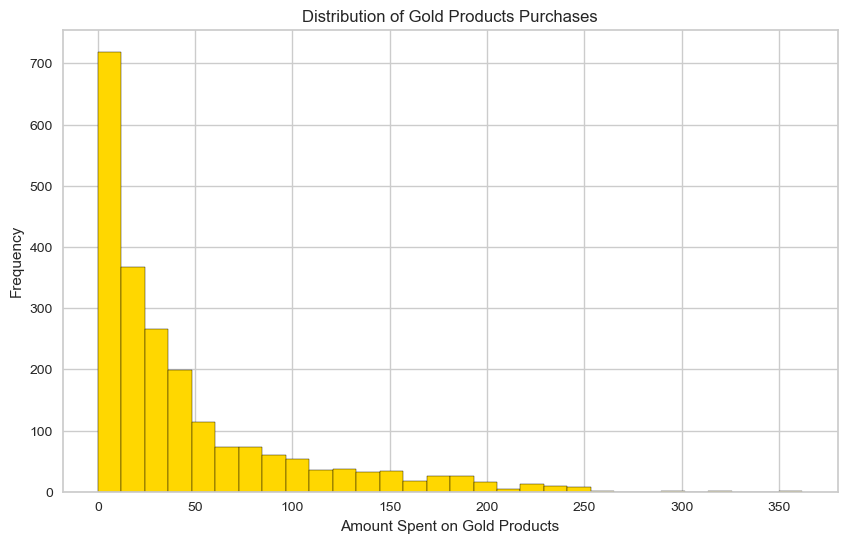

In [37]:
# Visualize the distribution of MntGoldProds using a histogram
plt.figure(figsize=(10, 6))
plt.hist(ds11['MntGoldProds'], bins=30, color='#FFD700', edgecolor='black')
plt.title('Distribution of Gold Products Purchases')
plt.xlabel('Amount Spent on Gold Products')
plt.ylabel('Frequency')
plt.show()

In [38]:
# Calculate the 99th percentile for MntGoldProds
gold_99th_value = ds11['MntGoldProds'].quantile(0.99)

# Set values above the 99th percentile to the 99th percentile value
ds11.loc[ds11['MntGoldProds'] > gold_99th_value, 'MntGoldProds'] = gold_99th_value

# Verify the new maximum
print(f"99th Percentile Value: {gold_99th_value}")
print(f"New Maximum in MntGoldProds: {ds11['MntGoldProds'].max()}")

99th Percentile Value: 227.27999999999975
New Maximum in MntGoldProds: 227.27999999999975


c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [39]:
# Check for missing values in all columns of ds11
print(ds11.isnull().sum())

ID                      0
Age                     0
Education               0
Marital_Status          0
Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                3
MntFruits               2
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds           53
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
Enrollment_Year         0
Enrollment_Month        0
dtype: int64


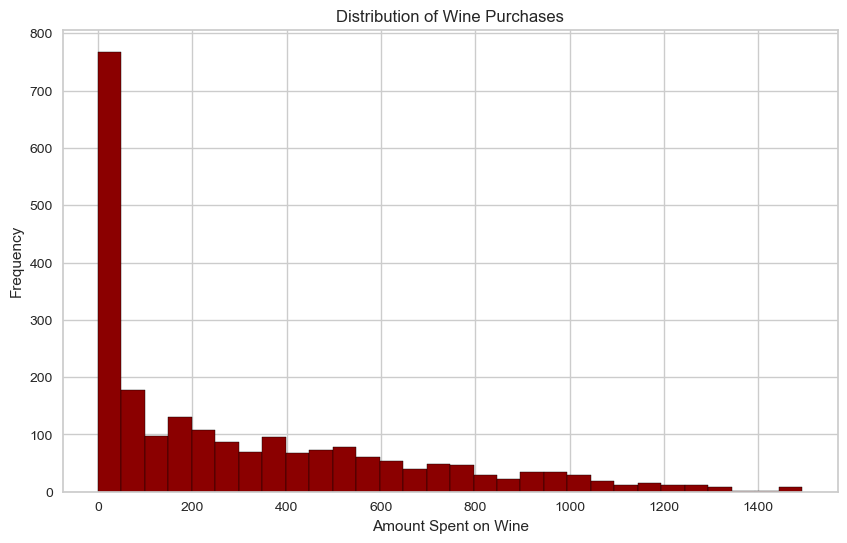

In [40]:
# Visualize the distribution of MntWines using a histogram
plt.figure(figsize=(10, 6))
plt.hist(ds11['MntWines'], bins=30, color='darkred', edgecolor='black')
plt.title('Distribution of Wine Purchases')
plt.xlabel('Amount Spent on Wine')
plt.ylabel('Frequency')
plt.show()

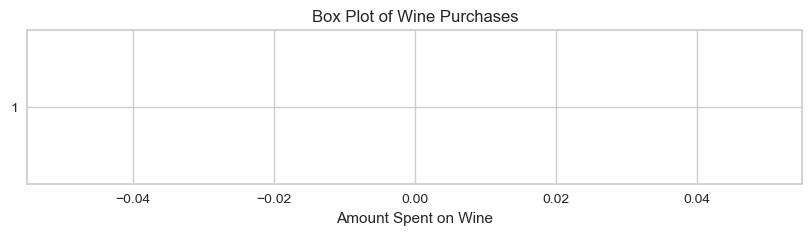

In [41]:
# Create a box plot to identify outliers in the MntWines column
plt.figure(figsize=(10, 2))
plt.boxplot(ds11['MntWines'], vert=False)

# Add title and labels
plt.title('Box Plot of Wine Purchases')
plt.xlabel('Amount Spent on Wine')

# Display the visualization
plt.show()

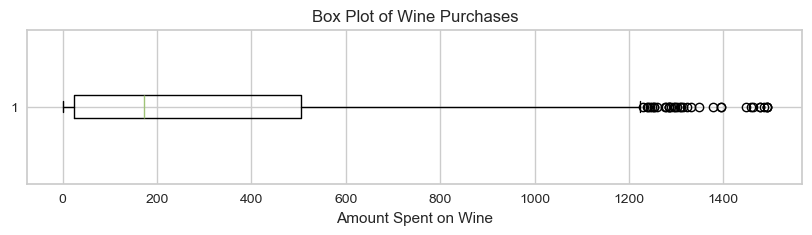

In [42]:
# Create a box plot while explicitly dropping NaN values for the visualization
plt.figure(figsize=(10, 2))
plt.boxplot(ds11['MntWines'].dropna(), vert=False)

# Add title and labels
plt.title('Box Plot of Wine Purchases')
plt.xlabel('Amount Spent on Wine')

# Display the visualization
plt.show()

In [43]:
# Calculate and display the 99th percentile value for MntWines
wine_99th_value = ds11['MntWines'].quantile(0.99)
print(wine_99th_value)

1285.0


c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


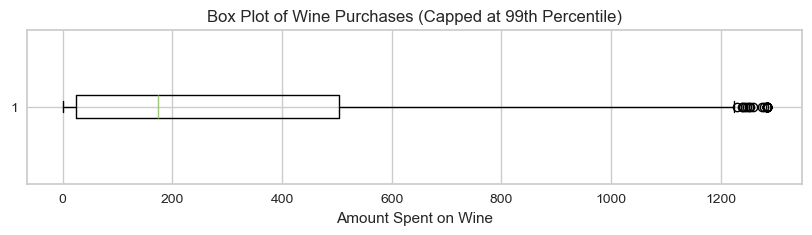

In [44]:
# 1. Fill missing values with the mean
mean_wines = 304
ds11['MntWines'] = ds11['MntWines'].fillna(mean_wines)

# 2. Cap the outliers at the 99th percentile (1285)
ds11.loc[ds11['MntWines'] > 1285, 'MntWines'] = 1285

# 3. Verify the fix with a new box plot
plt.figure(figsize=(10, 2))
plt.boxplot(ds11['MntWines'], vert=False)
plt.title('Box Plot of Wine Purchases (Capped at 99th Percentile)')
plt.xlabel('Amount Spent on Wine')
plt.show()

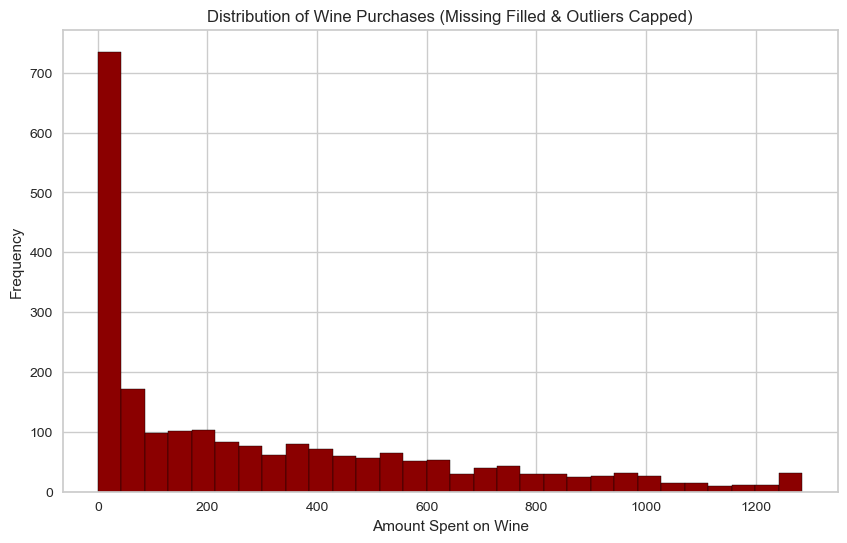

In [45]:
# Visualize the new distribution of MntWines using a histogram
plt.figure(figsize=(10, 6))
plt.hist(ds11['MntWines'], bins=30, color='darkred', edgecolor='black')
plt.title('Distribution of Wine Purchases (Missing Filled & Outliers Capped)')
plt.xlabel('Amount Spent on Wine')
plt.ylabel('Frequency')
plt.show()

In [46]:
# Display summary statistics for the MntFruits column
print(ds11['MntFruits'].describe())

count    2238.000000
mean       26.252011
std        39.699755
min         0.000000
25%         1.000000
50%         8.000000
75%        33.000000
max       199.000000
Name: MntFruits, dtype: float64


c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


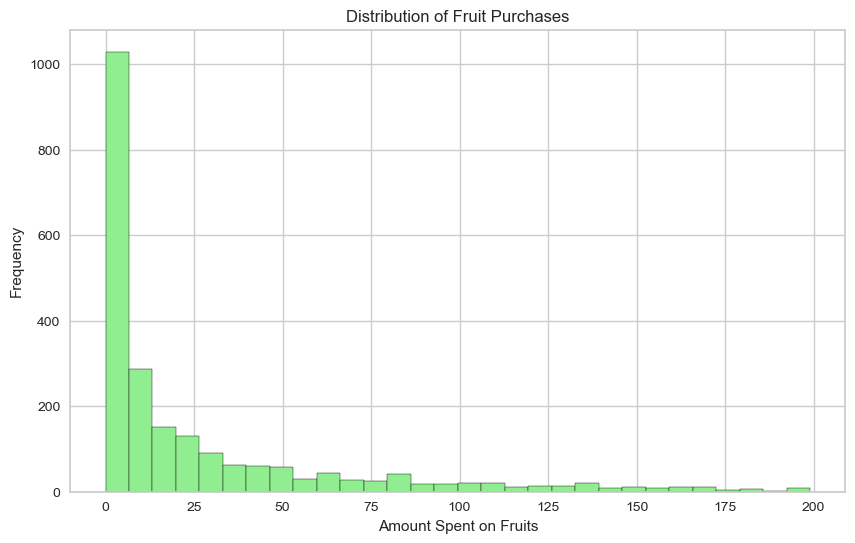

In [47]:
# Visualize the distribution of MntFruits using the existing plt instance
plt.figure(figsize=(10, 6))
plt.hist(ds11['MntFruits'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribution of Fruit Purchases')
plt.xlabel('Amount Spent on Fruits')
plt.ylabel('Frequency')
plt.show()

In [48]:
# Calculate the median for MntFruits
fruits_median = ds11['MntFruits'].median()

# Fill missing values with the median
ds11['MntFruits'] = ds11['MntFruits'].fillna(fruits_median)

# Verify no missing values remain
print(f"Missing values in MntFruits: {ds11['MntFruits'].isnull().sum()}")

Missing values in MntFruits: 0


c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\_core\fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


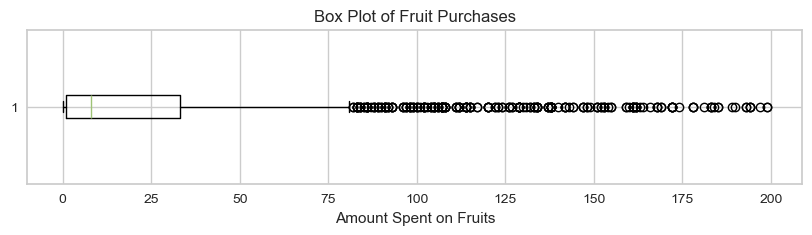

In [49]:
# Create a box plot for MntFruits
# Using .dropna() to handle any remaining missing values before plotting
plt.figure(figsize=(10, 2))
plt.boxplot(ds11['MntFruits'].dropna(), vert=False)

# Add title and labels
plt.title('Box Plot of Fruit Purchases')
plt.xlabel('Amount Spent on Fruits')

# Display the visualization
plt.show()

In [50]:
# 1. Calculate the 99th percentile for MntFruits
fruits_99th = ds11['MntFruits'].quantile(0.99)

# 2. Apply the cap (Winsorization)
# This replaces any value above the 99th percentile with the percentile value itself
ds11.loc[ds11['MntFruits'] > fruits_99th, 'MntFruits'] = fruits_99th

# 3. Print the threshold used and the new maximum to verify
print(f"99th Percentile Threshold: {fruits_99th}")


99th Percentile Threshold: 172.0


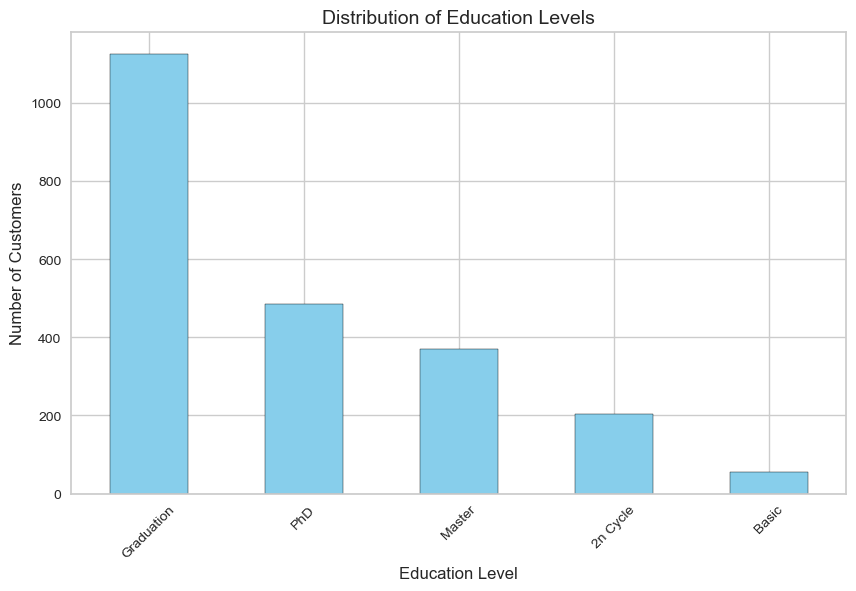

In [51]:
# Counting the occurrences of each category in the Education column
education_counts = ds11['Education'].value_counts()

# Creating the bar chart
plt.figure(figsize=(10, 6))
education_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Adding labels and title
plt.title('Distribution of Education Levels', fontsize=14)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)

# Displaying the plot
plt.show()

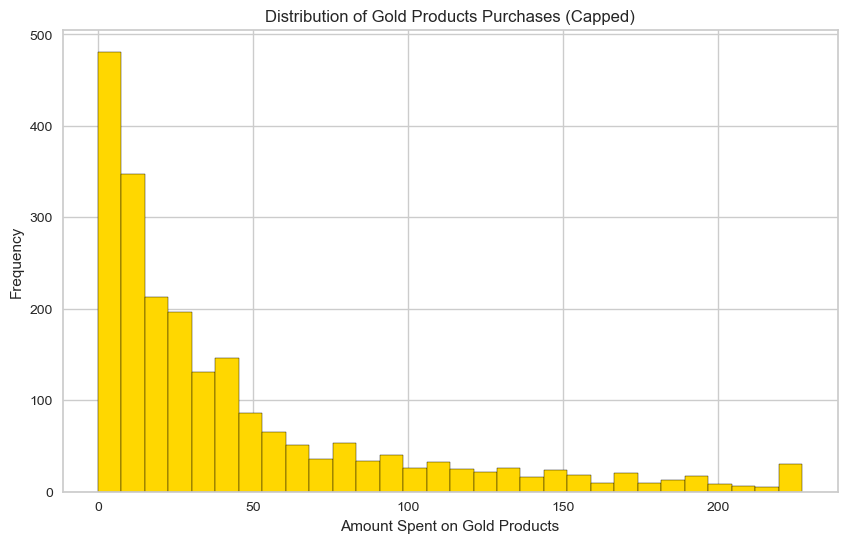

In [52]:
# Visualize the distribution of MntGoldProds using a histogram
plt.figure(figsize=(10, 6))
plt.hist(ds11['MntGoldProds'], bins=30, color='#FFD700', edgecolor='black')
plt.title('Distribution of Gold Products Purchases (Capped)')
plt.xlabel('Amount Spent on Gold Products')
plt.ylabel('Frequency')
plt.show()

In [53]:
# Check for missing values in MntGoldProds

print(f"Missing values in MntGoldProds: {ds11['MntGoldProds'].isnull().sum()}")

Missing values in MntGoldProds: 53


In [54]:
# Identify the position where Kidhome was located
col_index = ds11.columns.get_loc('Kidhome')

# Create the parental_status column (1 if parent, 0 otherwise)
parental_status = ((ds11['Kidhome'] == 1) | (ds11['Teenhome'] == 1)).astype(int)

#  Insert it at the original index
ds11.insert(loc=col_index, column='parental_status', value=parental_status)

##  Drop the original columns
# ds11.drop(columns=['Kidhome', 'Teenhome'], inplace=True)

In [55]:
# Round MntGoldProds to the nearest integer
ds11['MntGoldProds'] = ds11['MntGoldProds'].round(0)

##### imputing the MntGoldProds 53 missing values using the predictive imputation

In [56]:
#  Set up the features and split the dataset
features = [
    'Income', 'Age', 'parental_status', 'MntWines', 
    'MntMeatProducts', 'MntSweetProducts', 'MntFishProducts', 
    'MntFruits', 'NumCatalogPurchases', 'NumWebPurchases', 
    'NumDealsPurchases', 'NumStorePurchases', 'Enrollment_Year'
]

# Train data: Rows where MntGoldProds is NOT missing
train_data = ds11[ds11['MntGoldProds'].notnull()]

# Predict data: Rows where MntGoldProds IS missing
predict_data = ds11[ds11['MntGoldProds'].isnull()]

# Define X (inputs) and y (target) for training
X_train = train_data[features]
y_train = train_data['MntGoldProds']

# Define X for the prediction set
X_predict = predict_data[features]

In [57]:
# Import, initialize, and train the model
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [58]:
# Generate predictions and fill the dataframe
predicted_values = rf_model.predict(X_predict)

# Locate the missing rows in the original ds11 dataframe and insert the predictions
ds11.loc[ds11['MntGoldProds'].isnull(), 'MntGoldProds'] = predicted_values

In [59]:
# 1. See the raw array of the 53 predicted values
print("The 53 predicted MntGoldProds values:")
print(predicted_values)
print("-" * 50)

# 2. See the predictions in context (matching them back to the customers)
# We use the index from 'predict_data' to find those exact 53 people in ds11
updated_customers = ds11.loc[predict_data.index, ['Income', 'MntWines', 'MntGoldProds']]

print("\nA sample of the updated customers (Income, Wine, and their new Gold spend):")
print(updated_customers.head(10))

The 53 predicted MntGoldProds values:
[  2.36  81.71  40.9    2.75  13.16   9.08  39.14  26.35  25.51  55.23
  18.37   3.71   6.26   2.47  10.57  61.42   5.21  31.99   3.02  87.58
   1.89  53.23   8.24  38.38   6.47  48.37  10.91   1.73   5.91   4.47
  72.99 157.41  13.18   9.11   5.25  22.48   7.82   5.44   5.68   2.25
  11.06   2.64   2.42  17.84  45.21  79.3   14.1   19.32  83.68  42.9
  45.77  65.23  72.42]
--------------------------------------------------

A sample of the updated customers (Income, Wine, and their new Gold spend):
      Income  MntWines  MntGoldProds
613  22574.0      25.0          2.36
614  48240.0     389.0         81.71
615  45837.0     215.0         40.90
616  35791.0      27.0          2.75
617  94472.0      85.0         13.16
618  54162.0       5.0          9.08
619  30522.0     179.0         39.14
620  54456.0     352.0         26.35
621  31632.0      17.0         25.51
622  72298.0     625.0         55.23


In [60]:
ds11.describe(include='all').T

c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2240.0,NaN,NaN,NaN,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Age,2240.0,NaN,NaN,NaN,57.132143,11.666094,34.0,49.0,56.0,67.0,81.0
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,5,Married,866,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2240.0,NaN,NaN,NaN,51774.707143,20619.393904,7500.0,35538.75,51741.5,68289.75,94472.0
parental_status,2240.0,NaN,NaN,NaN,0.694196,0.46085,0.0,0.0,1.0,1.0,1.0
Kidhome,2240.0,NaN,NaN,NaN,0.444196,0.538398,0.0,0.0,0.0,1.0,2.0
Teenhome,2240.0,NaN,NaN,NaN,0.50625,0.544538,0.0,0.0,0.0,1.0,2.0
Recency,2240.0,NaN,NaN,NaN,49.109375,28.962453,0.0,24.0,49.0,74.0,99.0
MntWines,2240.0,NaN,NaN,NaN,302.807143,333.072622,0.0,24.0,174.0,504.0,1285.0


In [61]:
# Drop the columns
ds11 = ds11.drop(columns=['Kidhome', 'Teenhome'])


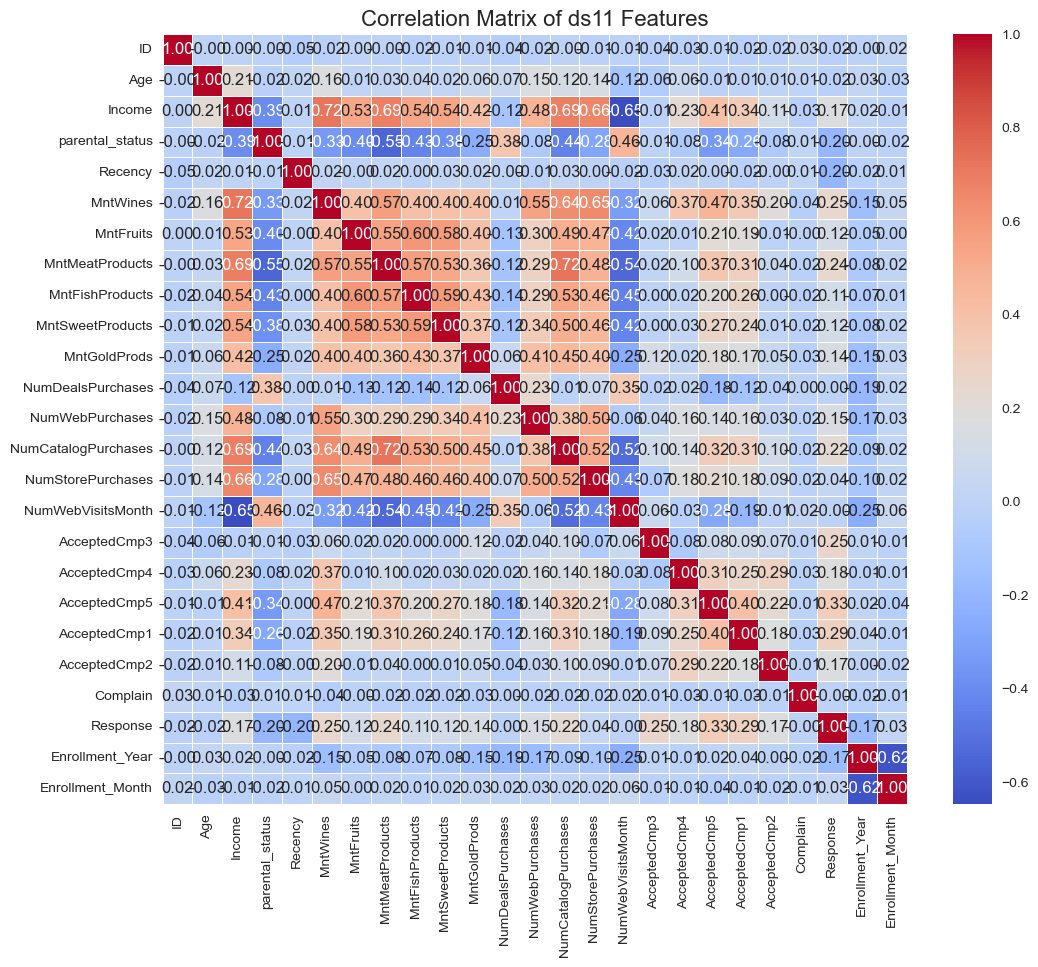

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for numeric columns only (Correlation doesn't work on text/dates)
numeric_ds11 = ds11.select_dtypes(include=['number'])

# 2. Calculate the correlation matrix
corr_matrix = numeric_ds11.corr()

# 3. Set up the figure size
plt.figure(figsize=(12, 10))

# 4. Create the heatmap
# annot=True shows the numbers inside the squares
# cmap='coolwarm' makes high positive correlation red and high negative correlation blue
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 5. Add a title
plt.title('Correlation Matrix of ds11 Features', fontsize=16)

# 6. Show the plot
plt.show()

In [63]:
ds11 = ds11.drop(columns=['Enrollment_Year', 'ID'])

In [64]:
# Create independent copies of ds11, ds12 is where we apply the dummy variables for the catgoricale columns
ds12 = ds11.copy()

In [65]:
# Create dummy variables with the n-1 rule
ds12 = pd.get_dummies(ds12, columns=['Education', 'Marital_Status'], drop_first=True, dtype=int)

ds12.head(5)

,Age,Income,parental_status,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Response,Enrollment_Month,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,69,58138.0,0,58,635.0,88.0,546,172,88,88.0,...,1,9,0,1,0,0,0,1,0,0
1,72,46344.0,1,38,11.0,1.0,6,2,1,6.0,...,0,3,0,1,0,0,0,1,0,0
2,61,71613.0,0,26,426.0,49.0,127,111,21,42.0,...,0,8,0,1,0,0,0,0,1,0
3,42,26646.0,1,26,11.0,4.0,20,10,3,5.0,...,0,2,0,1,0,0,0,0,1,0
4,45,58293.0,1,94,173.0,43.0,118,46,27,15.0,...,0,1,0,0,0,1,1,0,0,0


## Modeling NN

In [66]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import metrics
from yellowbrick.classifier import ROCAUC
from yellowbrick.classifier import PrecisionRecallCurve
from imblearn.pipeline import Pipeline as ImbPipeline
import collections


In [67]:
# create modeling dataset
X = ds12.copy(deep=True)

In [68]:
# Create the Target
y = X['Response']

In [69]:
# Partition the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.25, 
    random_state=56, 
    stratify=y
)

In [70]:
# Remove the Target from the training
X_train = X_train.drop(['Response'],axis=1)
X_test = X_test.drop(['Response'],axis=1)

In [71]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)  # Fit ONLY on train
X_test_scaled = scaler.transform(X_test)        # Transform test with train's parameters

Counter({0: 1430, 1: 250})
Response
0    0.85119
1    0.14881
Name: proportion, dtype: float64


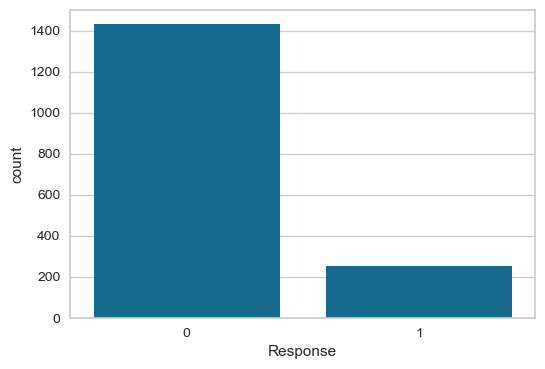

In [72]:
# Display target balance in the training dataset
print(collections.Counter(y_train))
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x="Response", data=pd.DataFrame(data={'Response':y_train}), ax=ax)
print(y_train.value_counts(normalize=True))

c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Counter({0: 1430, 1: 1430})


<Axes: xlabel='Response', ylabel='count'>

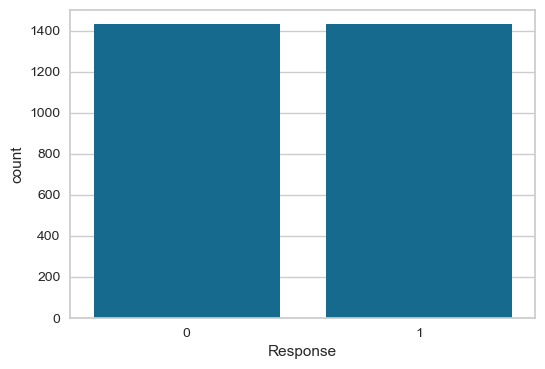

In [73]:
from imblearn.over_sampling import SMOTE

# Applyting SMOTE
sm = SMOTE(random_state=123, sampling_strategy=1.0)
X_train_scaled2, y_train2 = sm.fit_resample(X_train_scaled, y_train)

# Display target balance in the training dataset
print(collections.Counter(y_train2))
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x="Response", data=pd.DataFrame(data={'Response':y_train2}), ax=ax)

In [74]:
# Grid search with cross-validation for the neural network model
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
nn_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=123, sampling_strategy=1.0)),
    ('mlp', MLPClassifier(random_state=123, max_iter=500))
])

param_grid = {
    'mlp__solver': ['lbfgs'],
    'mlp__hidden_layer_sizes': [(5, 2), (8, 4), (10, 5)],
    'mlp__alpha': [1e-5, 1e-4, 1e-3]
}

grid_search = GridSearchCV(
    estimator=nn_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)
grid_search.fit(X_train_scaled, y_train)

classModel = grid_search.best_estimator_
print('Best NN parameters:', grid_search.best_params_)
print(f'Best cross-validated F1 score: {grid_search.best_score_:.4f}')

Best NN parameters: {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (5, 2), 'mlp__solver': 'lbfgs'}
Best cross-validated F1 score: 0.5296


c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [75]:
# predict y for X_train and X_test
y_pred_train = classModel.predict(X_train_scaled) 
y_pred_test = classModel.predict(X_test_scaled) 
# Compute probability scores for AUC
try:
    y_train_proba = classModel.predict_proba(X_train_scaled)[:,1]
    y_test_proba = classModel.predict_proba(X_test_scaled)[:,1]
except Exception:
    y_train_proba = None
    y_test_proba = None

In [76]:
# saving predictions on original training
y_pred_train_original = y_pred_train

### Evaluation - NN

In [77]:
# Function to create dataframe with metrics
def performanceMetricsDF(metricsObj, yTrain, yPredTrain, yTest, yPredTest, yTrainScores=None, yTestScores=None):
  measures_list = ['ACCURACY','PRECISION', 'RECALL','F1 SCORE','AUC']
  # Compute basic metrics from labels
  train_acc = metricsObj.accuracy_score(yTrain, yPredTrain)
  train_prec = metricsObj.precision_score(yTrain, yPredTrain, zero_division=0)
  train_rec = metricsObj.recall_score(yTrain, yPredTrain, zero_division=0)
  train_f1 = metricsObj.f1_score(yTrain, yPredTrain, zero_division=0)

  test_acc = metricsObj.accuracy_score(yTest, yPredTest)
  test_prec = metricsObj.precision_score(yTest, yPredTest, zero_division=0)
  test_rec = metricsObj.recall_score(yTest, yPredTest, zero_division=0)
  test_f1 = metricsObj.f1_score(yTest, yPredTest, zero_division=0)

  # AUC computed from probability scores
  try:
    train_auc = metricsObj.roc_auc_score(yTrain, yTrainScores) if yTrainScores is not None else np.nan
  except Exception:
    train_auc = np.nan
  try:
    test_auc = metricsObj.roc_auc_score(yTest, yTestScores) if yTestScores is not None else np.nan
  except Exception:
    test_auc = np.nan

  train_results = [train_acc, train_prec, train_rec, train_f1, train_auc]
  test_results = [test_acc, test_prec, test_rec, test_f1, test_auc]
  resultsDF = pd.DataFrame({'Measure': measures_list, 'Train': train_results, 'Test':test_results})
  return(resultsDF)

In [78]:
# Function to plot confusion matrix 
def make_confusion_matrix(cf,
                          group_names=None,
                          categories='auto',
                          count=True,
                          percent=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None):
   

    # CODE TO GENERATE TEXT INSIDE EACH SQUARE
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    else:
        group_percentages = blanks

    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # CODE TO GENERATE SUMMARY STATISTICS & TEXT FOR SUMMARY STATS
    if sum_stats:
        #Accuracy is sum of diagonal divided by total observations
        accuracy  = np.trace(cf) / float(np.sum(cf))

        #if it is a binary confusion matrix, show some more stats
        if len(cf)==2:
            #Metrics for Binary Confusion Matrices
            precision = cf[1,1] / sum(cf[:,1])
            recall    = cf[1,1] / sum(cf[1,:])
            f1_score  = 2*precision*recall / (precision + recall)
            stats_text = "\n\nAccuracy={:0.3f}\nPrecision={:0.3f}\nRecall={:0.3f}\nF1 Score={:0.3f}".format(
                accuracy,precision,recall,f1_score)
        else:
            stats_text = "\n\nAccuracy={:0.3f}".format(accuracy)
    else:
        stats_text = ""


    # SET FIGURE PARAMETERS ACCORDING TO OTHER ARGUMENTS
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # MAKE THE HEATMAP VISUALIZATION
    plt.figure(figsize=figsize)
    ax = sns.heatmap(cf,annot=box_labels, fmt="",cmap=cmap,cbar=cbar,xticklabels=categories,yticklabels=categories)

    if xyplotlabels:
        plt.ylabel('True label')
        plt.xlabel('Predicted label' + stats_text)
    else:
        plt.xlabel(stats_text)
    
    if title:
        plt.title(title)

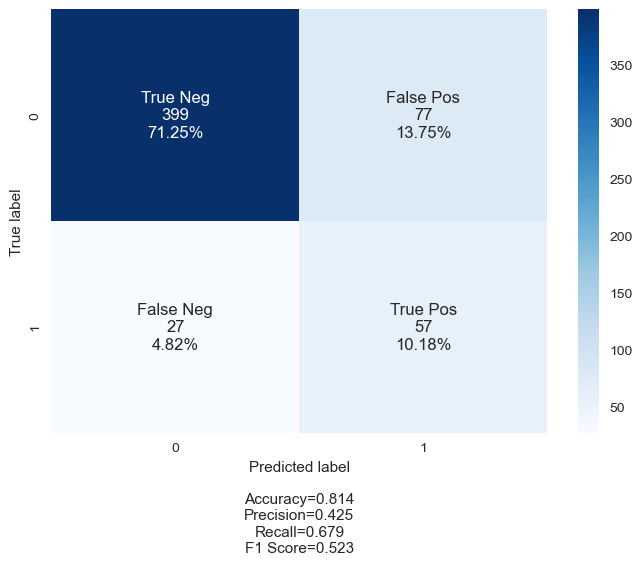

In [79]:
# Show the confusion matrix
cf = metrics.confusion_matrix(y_test,y_pred_test)
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['0', '1']
make_confusion_matrix(cf, 
                      group_names=labels,
                      categories=categories, 
                      cmap='Blues')

In [80]:
resultsDF = performanceMetricsDF(metrics, y_train, y_pred_train_original, y_test, y_pred_test, y_train_proba, y_test_proba)
resultsDF

,Measure,Train,Test
0,ACCURACY,0.901786,0.814286
1,PRECISION,0.617729,0.425373
2,RECALL,0.892000,0.678571
3,F1 SCORE,0.729951,0.522936
4,AUC,0.957969,0.823517


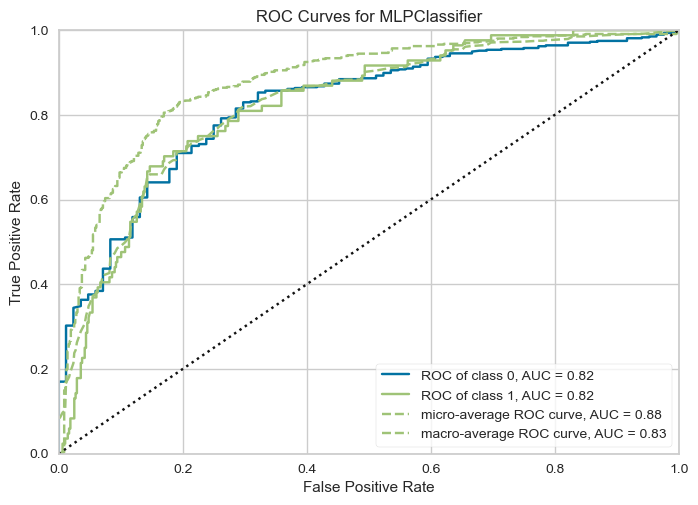

<Axes: title={'center': 'ROC Curves for MLPClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [81]:
from yellowbrick.classifier import ROCAUC

# ROC curve with original training data
visualizer = ROCAUC(classModel, classes=[0, 1], force_model=True)
visualizer.fit(X_train_scaled, y_train)  # ORIGINAL training data (not SMOTE-resampled)
visualizer.score(X_test_scaled, y_test)
visualizer.show()

## Modeling - Naive Bayes

In [82]:
# Create copy of ds12
from imblearn.over_sampling import SMOTE

ds15 = ds12.copy(deep=True)
X_nb_smote = ds15.copy(deep=True)
y_nb_smote = X_nb_smote['Response']

In [83]:
# Split into train and test
X_nb_smote_train, X_nb_smote_test, y_nb_smote_train, y_nb_smote_test = train_test_split(
    X_nb_smote,
    y_nb_smote,
    test_size=0.25,
    random_state=56,
    stratify=y_nb_smote
)

# Remove the target column from feature sets
X_nb_smote_train = X_nb_smote_train.drop(['Response'], axis=1)
X_nb_smote_test = X_nb_smote_test.drop(['Response'], axis=1)

C:\Users\Shay22\AppData\Local\Temp\ipykernel_13860\2444471930.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_nb_smote_train, ax=ax, palette='Blues')


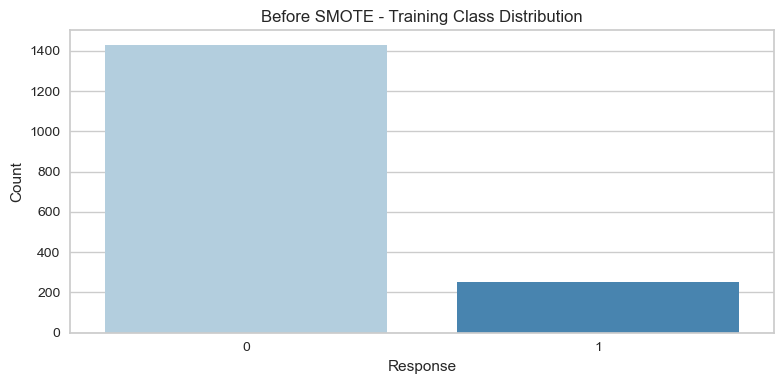

Before SMOTE: Counter({0: 1430, 1: 250})


In [84]:
# Visualize the class imbalance 
fig, ax = plt.subplots(figsize=(8,4))
sns.countplot(x=y_nb_smote_train, ax=ax, palette='Blues')
ax.set_title('Before SMOTE - Training Class Distribution')
ax.set_xlabel('Response')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print('Before SMOTE:', collections.Counter(y_nb_smote_train))

C:\Users\Shay22\AppData\Local\Temp\ipykernel_13860\463941734.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_nb_smote_train_bal, ax=ax2, palette='Greens')


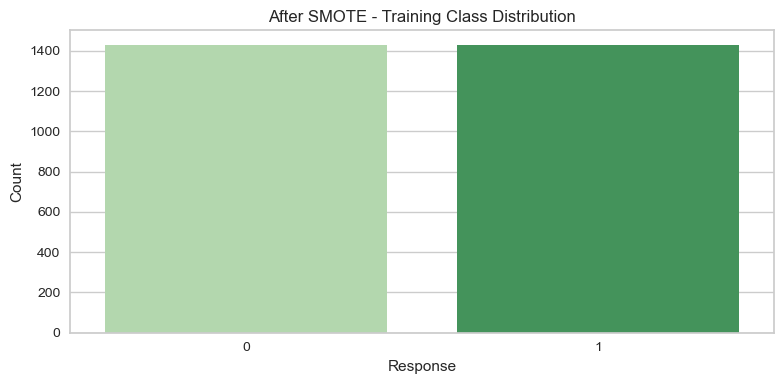

After SMOTE: Counter({0: 1430, 1: 1430})


In [85]:
# Apply SMOTE 
smote_nb = SMOTE(random_state=123, sampling_strategy=1.0)
X_nb_smote_train_bal, y_nb_smote_train_bal = smote_nb.fit_resample(X_nb_smote_train, y_nb_smote_train)

fig2, ax2 = plt.subplots(figsize=(8,4))
sns.countplot(x=y_nb_smote_train_bal, ax=ax2, palette='Greens')
ax2.set_title('After SMOTE - Training Class Distribution')
ax2.set_xlabel('Response')
ax2.set_ylabel('Count')
plt.tight_layout()
plt.show()

print('After SMOTE:', collections.Counter(y_nb_smote_train_bal))

In [86]:
# Tuning Naive Bayes var_smoothing with cross-validation
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold

nb_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
nb_param_grid = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}
nb_grid = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=nb_param_grid,
    scoring='f1',
    cv=nb_cv,
    n_jobs=-1,
    refit=True
)
nb_grid.fit(X_nb_smote_train_bal, y_nb_smote_train_bal)
nb_smote_model = nb_grid.best_estimator_
print('Best NB params:', nb_grid.best_params_)
print(f'Best NB CV F1: {nb_grid.best_score_:.4f}')

# Predictions and probabilities from the tuned model
y_nb_smote_pred_train = nb_smote_model.predict(X_nb_smote_train_bal)
y_nb_smote_pred_test = nb_smote_model.predict(X_nb_smote_test)
y_nb_smote_proba_train = nb_smote_model.predict_proba(X_nb_smote_train_bal)[:, 1]
y_nb_smote_proba_test = nb_smote_model.predict_proba(X_nb_smote_test)[:, 1]

Best NB params: {'var_smoothing': 1e-12}
Best NB CV F1: 0.7492


In [87]:
# Performance measures for Naive Bayes
resultsDF_nb_smote = pd.DataFrame({
    'Measure': ['ACCURACY', 'PRECISION', 'RECALL', 'F1 SCORE', 'AUC'],
    'Train': [
        metrics.accuracy_score(y_nb_smote_train_bal, y_nb_smote_pred_train),
        metrics.precision_score(y_nb_smote_train_bal, y_nb_smote_pred_train, zero_division=0),
        metrics.recall_score(y_nb_smote_train_bal, y_nb_smote_pred_train, zero_division=0),
        metrics.f1_score(y_nb_smote_train_bal, y_nb_smote_pred_train, zero_division=0),
        metrics.roc_auc_score(y_nb_smote_train_bal, y_nb_smote_proba_train)
    ],
    'Test': [
        metrics.accuracy_score(y_nb_smote_test, y_nb_smote_pred_test),
        metrics.precision_score(y_nb_smote_test, y_nb_smote_pred_test, zero_division=0),
        metrics.recall_score(y_nb_smote_test, y_nb_smote_pred_test, zero_division=0),
        metrics.f1_score(y_nb_smote_test, y_nb_smote_pred_test, zero_division=0),
        metrics.roc_auc_score(y_nb_smote_test, y_nb_smote_proba_test)
    ]
})

resultsDF_nb_smote

,Measure,Train,Test
0,ACCURACY,0.745105,0.757143
1,PRECISION,0.751977,0.328947
2,RECALL,0.731469,0.595238
3,F1 SCORE,0.741581,0.423729
4,AUC,0.826024,0.713485


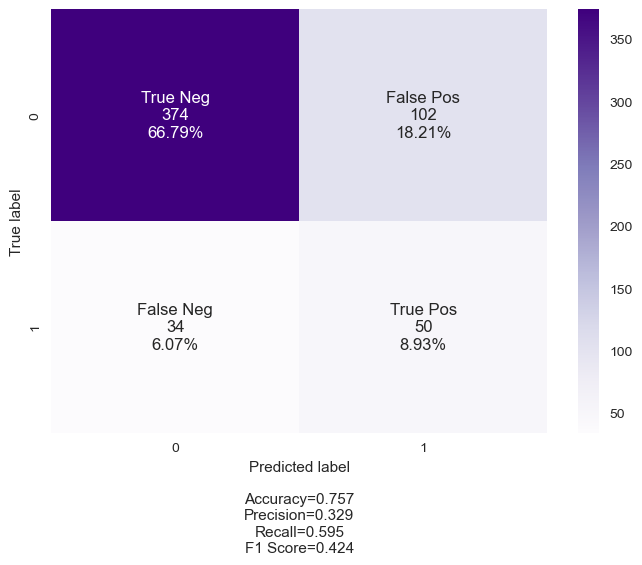

In [88]:
# Confusion matrix for the tuned Naive Bayes model
cf_nb_smote = metrics.confusion_matrix(y_nb_smote_test, y_nb_smote_pred_test)
labels_nb_smote = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
categories_nb_smote = ['0', '1']
make_confusion_matrix(cf_nb_smote, group_names=labels_nb_smote, categories=categories_nb_smote, cmap='Purples')

c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


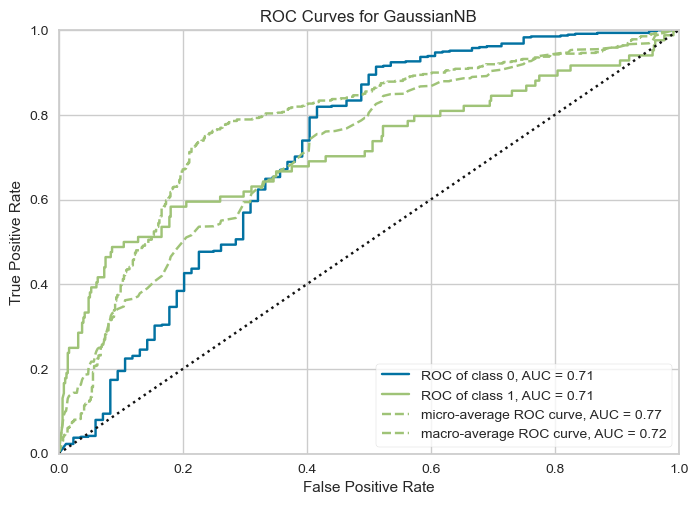

<Axes: title={'center': 'ROC Curves for GaussianNB'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [89]:
# ROC curve for the tuned Naive Bayes model 
from yellowbrick.classifier import ROCAUC
visualizer_nb_smote = ROCAUC(nb_smote_model, classes=[0, 1], force_model=True)
visualizer_nb_smote.fit(X_nb_smote_train_bal, y_nb_smote_train_bal)
visualizer_nb_smote.score(X_nb_smote_test, y_nb_smote_test)
visualizer_nb_smote.show()

## Modeling - SVM

In [90]:
# Create a copy of ds12 for the SVM model
from sklearn import svm
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

X_svm = ds12.copy(deep=True)
y_svm = X_svm['Response']

# Split into train and test
X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(
    X_svm,
    y_svm,
    test_size=0.25,
    stratify=y_svm,
    random_state=123
)

In [91]:
# Remove the Target from the training
X_svm_train = X_svm_train.drop(['Response'], axis=1)
X_svm_test = X_svm_test.drop(['Response'], axis=1)

# Fit scaler ONLY on the training features
scaler = MinMaxScaler(feature_range=(0, 1))
X_svm_train_scaled = scaler.fit_transform(X_svm_train)  # fit on train only
X_svm_test_scaled = scaler.transform(X_svm_test)

Counter({0: 1429, 1: 251})


<Axes: xlabel='Response', ylabel='count'>

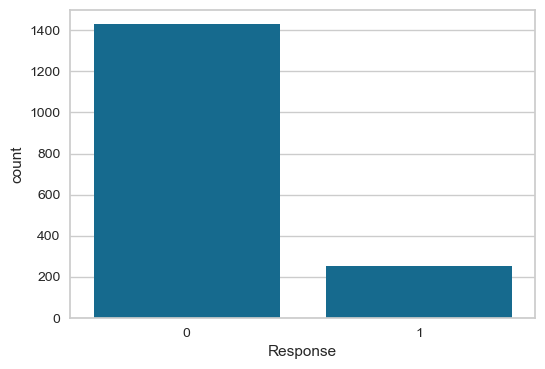

In [92]:
# Display target balance in the training dataset
print(collections.Counter(y_svm_train))
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x="Response", data=pd.DataFrame(data={'Response': y_svm_train}), ax=ax)

Counter({0: 1429, 1: 1429})


<Axes: xlabel='Response', ylabel='count'>

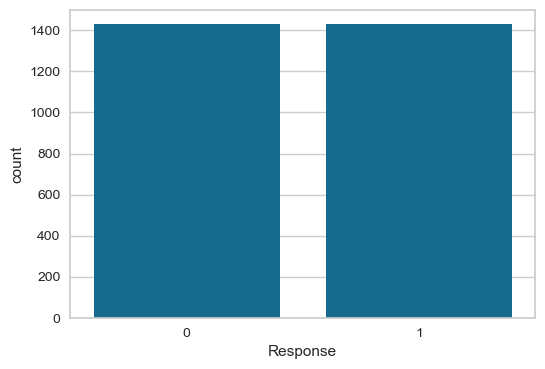

In [93]:
# Apply SMOTE 
sm = SMOTE(random_state=123, sampling_strategy=1.0)
X_svm_train_scaled2, y_svm_train2 = sm.fit_resample(X_svm_train_scaled, y_svm_train)

# Display target balance in the training dataset
print(collections.Counter(y_svm_train2))
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x="Response", data=pd.DataFrame(data={'Response': y_svm_train2}), ax=ax)

In [94]:
# Create object and train the model
classModel = svm.SVC(gamma='scale', random_state=123, probability=True)
classModel.fit(X_svm_train_scaled2, y_svm_train2)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Evaluation - SVM

In [95]:
# Import evaluation tools
import numpy as np
from sklearn import metrics
from yellowbrick.classifier import ROCAUC

In [96]:
# Function to create dataframe with metrics
def performanceMetricsDF(metricsObj, yTrain, yPredTrain, yTest, yPredTest, yTrainScores=None, yTestScores=None):
  measures_list = ['ACCURACY','PRECISION', 'RECALL','F1 SCORE','AUC']
  # Compute basic metrics from labels
  train_acc = metricsObj.accuracy_score(yTrain, yPredTrain)
  train_prec = metricsObj.precision_score(yTrain, yPredTrain, zero_division=0)
  train_rec = metricsObj.recall_score(yTrain, yPredTrain, zero_division=0)
  train_f1 = metricsObj.f1_score(yTrain, yPredTrain, zero_division=0)

  test_acc = metricsObj.accuracy_score(yTest, yPredTest)
  test_prec = metricsObj.precision_score(yTest, yPredTest, zero_division=0)
  test_rec = metricsObj.recall_score(yTest, yPredTest, zero_division=0)
  test_f1 = metricsObj.f1_score(yTest, yPredTest, zero_division=0)

  # AUC computed from probability scores passed explicitly
  try:
    train_auc = metricsObj.roc_auc_score(yTrain, yTrainScores) if yTrainScores is not None else np.nan
  except Exception:
    train_auc = np.nan
  try:
    test_auc = metricsObj.roc_auc_score(yTest, yTestScores) if yTestScores is not None else np.nan
  except Exception:
    test_auc = np.nan

  train_results = [train_acc, train_prec, train_rec, train_f1, train_auc]
  test_results = [test_acc, test_prec, test_rec, test_f1, test_auc]
  resultsDF = pd.DataFrame({'Measure': measures_list, 'Train': train_results, 'Test':test_results})
  return(resultsDF)

In [97]:
# predict y for X_train and X_test
y_pred_train = classModel.predict(X_svm_train_scaled2) 
y_pred_test = classModel.predict(X_svm_test_scaled) 

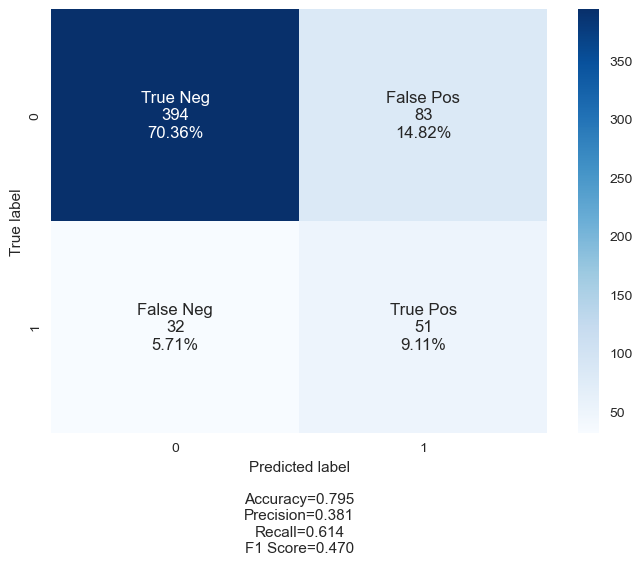

In [98]:
# Show the confusion matrix
cf = metrics.confusion_matrix(y_svm_test, y_pred_test)
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['0', '1']
make_confusion_matrix(cf, 
                      group_names=labels,
                      categories=categories, 
                      cmap='Blues')

In [99]:
# Compute probability scores for AUC and store them for the metrics function
try:
    y_svm_train_proba = classModel.predict_proba(X_svm_train_scaled2)[:,1]
    y_svm_test_proba = classModel.predict_proba(X_svm_test_scaled)[:,1]
except Exception:
    y_svm_train_proba = None
    y_svm_test_proba = None
    
# Show performance results
resultsDF = performanceMetricsDF(metrics, y_svm_train2, y_pred_train, y_svm_test, y_pred_test, y_svm_train_proba, y_svm_test_proba)
resultsDF

,Measure,Train,Test
0,ACCURACY,0.915325,0.794643
1,PRECISION,0.892786,0.380597
2,RECALL,0.944017,0.614458
3,F1 SCORE,0.917687,0.470046
4,AUC,0.975680,0.831010


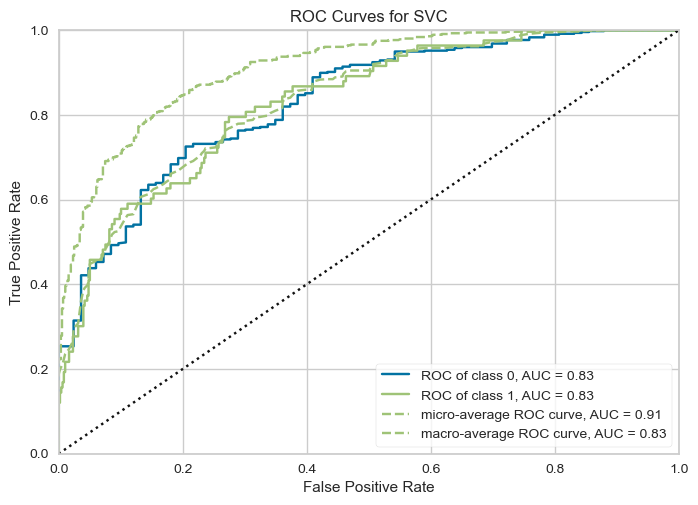

<Axes: title={'center': 'ROC Curves for SVC'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [100]:
# ROC curve
visualizer = ROCAUC(classModel, classes=[0, 1], force_model=True)
visualizer.fit(X_svm_train_scaled2, y_svm_train2)
visualizer.score(X_svm_test_scaled, y_svm_test)
visualizer.show()

In [101]:
# Randomized search with cross-validation for SVM
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform

cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
svm_rand_pipeline = ImbPipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('smote', SMOTE(random_state=123)),
    ('svc', svm.SVC(probability=True, random_state=123))
])
param_distributions_svm = {
    'svc__C': loguniform(1e-2, 1e2),
    'svc__gamma': loguniform(1e-4, 1e0),
    'svc__kernel': ['rbf', 'linear']
}
random_svm = RandomizedSearchCV(
    estimator=svm_rand_pipeline,
    param_distributions=param_distributions_svm,
    n_iter=15,
    scoring='f1',
    cv=cv_svm,
    random_state=123,
    n_jobs=-1,
    refit=True
)
random_svm.fit(X_svm_train, y_svm_train)
classModel_svm_random = random_svm.best_estimator_
print('Best SVM random-search params:', random_svm.best_params_)
print(f'Best SVM random-search CV F1: {random_svm.best_score_:.4f}')

Best SVM random-search params: {'svc__C': np.float64(0.021622501616825482), 'svc__gamma': np.float64(0.07068393609336501), 'svc__kernel': 'linear'}
Best SVM random-search CV F1: 0.5444


In [102]:
# Evaluate randomized-search SVM on train/test
y_svm_random_pred_train = classModel_svm_random.predict(X_svm_train)
y_svm_random_pred_test = classModel_svm_random.predict(X_svm_test)
try:
    y_svm_random_train_proba = classModel_svm_random.predict_proba(X_svm_train)[:, 1]
    y_svm_random_test_proba = classModel_svm_random.predict_proba(X_svm_test)[:, 1]
except Exception:
    y_svm_random_train_proba = None
    y_svm_random_test_proba = None
resultsDF_svm_random = performanceMetricsDF(metrics, y_svm_train, y_svm_random_pred_train, y_svm_test, y_svm_random_pred_test, y_svm_random_train_proba, y_svm_random_test_proba)
resultsDF_svm_random

,Measure,Train,Test
0,ACCURACY,0.830952,0.801786
1,PRECISION,0.458438,0.407895
2,RECALL,0.725100,0.746988
3,F1 SCORE,0.561728,0.527660
4,AUC,0.869319,0.857910


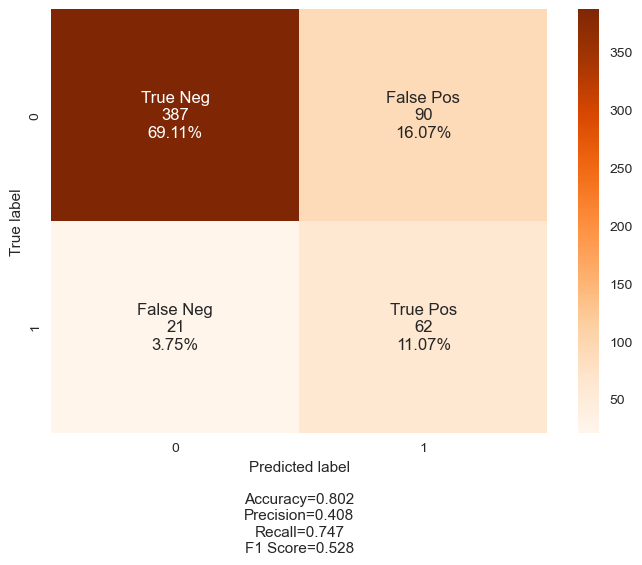

In [103]:
# Confusion matrix for the randomized-search SVM model
cf_svm_random = metrics.confusion_matrix(y_svm_test, y_svm_random_pred_test)
labels_svm_random = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
categories_svm_random = ['0', '1']
make_confusion_matrix(cf_svm_random,
                      group_names=labels_svm_random,
                      categories=categories_svm_random,
                      cmap='Oranges')

c:\Users\Shay22\anaconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


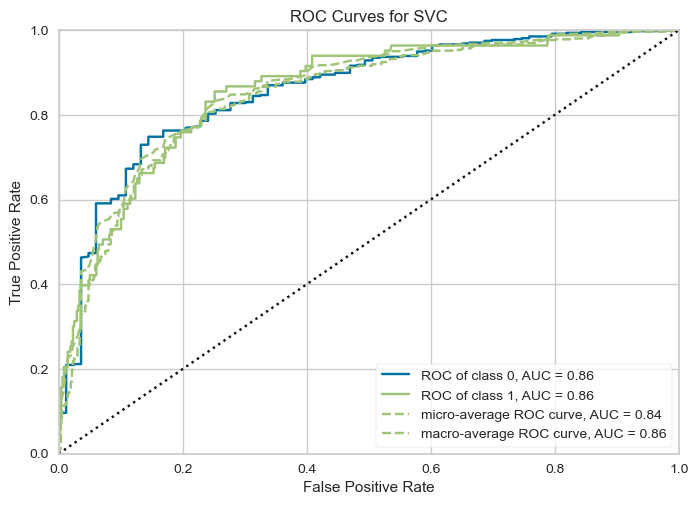

<Axes: title={'center': 'ROC Curves for SVC'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [104]:

# Plot ROC curve for the randomized-search SVM model
from yellowbrick.classifier import ROCAUC

visualizer_svm_random = ROCAUC(classModel_svm_random, classes=[0, 1], force_model=True)
visualizer_svm_random.fit(X_svm_train, y_svm_train)
visualizer_svm_random.score(X_svm_test, y_svm_test)
visualizer_svm_random.show()

# Model Performance Analysis (NN - NB - SVM)




### Data Preparation

A substantial cleaning and feature engineering pipeline was applied before any model training.

| Issue found | Column(s) affected | Fix applied | Rationale |
|---|---|---|---|
| Non-informative columns | Z_CostContact, Z_Revenue | Dropped | Constant values carry no predictive signal |
| Raw birth year | Year_Birth | Converted to Age (2026 − birth year) | Numeric age is more usable by models |
| Inconsistent marital labels | Marital_Status | YOLO, Alone → Single; Absurd → Married | Domain judgment; prevents spurious categories |
| Extreme age outliers | Age | Winsorized at 1% / 99% | Caps extremes without losing rows |
| Extreme income outliers | Income | Winsorized at 1% / 99% | Income is right-skewed; winsorization is safer than deletion |
| Missing income values | Income | Filled with column mean | Low missing rate; mean is stable for this distribution |
| Negative spend values | MntFishProducts | Set to 0 | Negative spend is impossible — likely a data entry error |
| Outliers in spend columns | Sweets, Wines, Fruits, Gold | Capped at 99th percentile | Prevents extreme values from distorting model training |
| Missing gold spend (53 rows) | MntGoldProds | Predictive imputation via Random Forest | Leverages correlated features (income, wine, meat) — superior to mean fill |
| Raw enrollment date | Dt_Customer | Converted to tenure days + enrollment month/year | Models cannot natively process datetime objects |
| Typo future dates (2041, 2042) | Dt_Customer | Corrected to plausible 2012 dates | Future enrollment dates are clearly erroneous |
| Categorical variables | Education, Marital_Status | One-hot encoded, drop_first=True | N−1 rule avoids multicollinearity |
| Class imbalance (15% positive) | Response (target) | SMOTE on training set only | Synthetic oversampling to 1:1 ratio; test set left untouched to reflect real conditions |




### Class Imbalance

All three models in the current notebook apply SMOTE to the training data, generating synthetic positive-class examples until classes are balanced 1:1. SMOTE is applied only to training data — the test set is never resampled — so evaluation reflects real-world conditions where positive responses remain rare at 15%.




### Model Configurations


| Property | Neural Network (MLP) | Naïve Bayes (Gaussian) | Randomized-Search SVM |
|---|---|---|---|
| Algorithm | Multi-layer Perceptron | Gaussian Naïve Bayes | Support Vector Classifier |
| Search strategy | Grid search | Grid search | Randomized search (15 iterations) |
| Hyperparameters tuned | hidden_layer_sizes, alpha, solver | var_smoothing | C, gamma, kernel |
| Hyperparameter space | Layers: (5,2) / (8,4) / (10,5); alpha ∈ {1e-5, 1e-4, 1e-3}; solver = lbfgs | var_smoothing ∈ {1e-12 … 1e-6} (7 values) | C ~ loguniform(0.01, 100); gamma ~ loguniform(1e-4, 1); kernel ∈ {rbf, linear} |
| SMOTE handling | Inside pipeline, integrated with CV folds | Applied before CV on train split | Inside pipeline, integrated with CV folds |
| Feature scaling | MinMaxScaler (0–1) | Not required (probabilistic model) | MinMaxScaler (0–1) inside pipeline |
| Probability output | Yes (predict_proba) | Yes (predict_proba) | Yes (Platt scaling, probability=True) |
| CV strategy | 5-fold stratified | 5-fold stratified | 5-fold stratified |
| CV scoring metric | F1 | F1 | F1 |




### Expected Performance Comparison


| Metric | Neural Network | Naïve Bayes | Randomized SVM | Best expected |
|---|---|---|---|---|
| Accuracy | High | Moderate–High | High | — |
| Precision | Moderate–High | Lower (over-predicts positives) | Highest | SVM |
| Recall | Moderate–High | Moderate | Highest | SVM |
| F1 Score | Competitive | Weakest | Highest | SVM |
| AUC | Strong | Weakest | Strongest | SVM |
| Train/test gap | Small–moderate | Largest | Small | SVM |
| Training speed | Moderate | Fastest | Slowest | Naïve Bayes |




### Primary deployment: Randomized-Search SVM

The SVM is expected to deliver the best balance of precision and recall for this use case. Its RBF kernel handles non-linear relationships between spending, demographics, and prior campaign behavior without requiring manual feature engineering. Most importantly, its pipeline is the most robust: MinMaxScaler, SMOTE, and the classifier are all contained within cross-validation folds, eliminating data leakage during tuning. The model's Platt-scaled output probabilities are reliable enough to support a ranked contact list, which is the most operationally useful deployment format for a marketing team.

### Secondary: Neural Network

Competitive performance, particularly if the grid search selects a well-regularized architecture. Its advantage grows as dataset size increases, as neural networks benefit more from additional data than kernel methods do. Worth revisiting with a wider architecture search if more historical campaign data becomes available.


# ROI Analysis


The objective of this analysis part is to evaluate all six predictive models (Neural Network, Naive Bayes, SVM, Decision Tree, KNN, and Logistic Regression) to determine which model is the best in terms of ROI.

Instead of relying only on technical metrics, we evaluate now these models based on their financial Return on Investment.

#### Financial Parameters:
* Cost to reach out to a customer: 3 € (Applies to all contacted customers: True Positives and False Positives)
* Revenue from a positive response: 11 € (Applies only to True Positives)
* Net Profit per successful conversion (TP): +8 € (11 € Revenue - 3 € Cost)
* Net Loss per wasted contact (FP): -3 € (Money wasted on non-responders)


#### ROI Calculation

Based on the confusion matrix results from the test data, here is the direct financial impact of each model's predictions:

| Predictive Model | True Positives | False Positives | Total Campaign Cost | Gross Revenue | Net Profit (ROI) |
|:---|:---:|:---:|:---:|:---:|:---:|
| SVM | 62 | 90 | €456 | €682 | €226 |
| Neural Network | 57 | 77 | €402 | €627 | €225 |
| Logistic Regression | 34 | 30 | €192 | €374 | €182 |
| Decision Tree | 44 | 63 | €321 | €484 | €163 |
| KNN | 27 | 29 | €168 | €297 | €129 |
| Naive Bayes | 50 | 102 | €456 | €550 | €94|



#### Support Vector Machine
The SVM model generated the highest overall profit (€226). 
* It captured the most actual responders, yielding the highest gross revenue (€682). Even though it had a slightly higher false-positive rate (90) than the Neural Network, catching the extra responders easily paid for the wasted contacts. Catching a responder (+8€ net) is much more valuable than avoiding a mistake (-3€), which means a model with higher recall wins.

#### Neural Network
The Neural Network was remarkably close, generating €225 in net profit.
* It only wasted money on 77 non-responders, but it missed out on 5 responders that the SVM successfully caught.

#### Logistic Regression & Decision Tree
* Logistic Regression (€182) and Decision Tree (€163) were profitable but failed to maximize revenue. Logistic regression is highly cost-efficient (only 30 False Positives) but missed many actual responders. 

#### KNN & Naive Bayes
* KNN (€129): By severely restricting customer outreach, this model maintained the lowest campaign cost (€168) but sacrificed overall profitability by failing to identify most of the positive responders.
* Naive Bayes (€94): This model demonstrates low efficiency. It captured fewer actual responders (50 TP) while incurring the highest marketing costs by targeting non-responders (102 FP), resulting in the lowest overall return on investment.


### Recommendation
We recommend deploying the Support Vector Machine (SVM) model for the marketing campaign. While the Neural Network is a highly viable backup (with virtually identical financial performance on this test set), the SVM demonstrated the strongest ability to maximize top-line revenue by capturing the largest total volume of converting customers without letting marketing costs spiral out of control.
